## 1.Import Libraries

In [24]:
# IMPORT REQUIRED LIBRARIES
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Model Selection and Validation
from sklearn.model_selection import (
    train_test_split,      # Split data into train and test sets
    cross_val_score,       # Perform cross-validation
    StratifiedKFold,       # Stratified K-Fold for imbalanced data
    GridSearchCV           # Hyperparameter tuning
)

from sklearn.preprocessing import LabelEncoder  # Encode categorical labels
from sklearn.ensemble import RandomForestClassifier

#Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,        # Overall accuracy
    precision_score,       # Precision (positive predictive value)
    recall_score,          # Recall (sensitivity)
    f1_score,              # F1-Score (harmonic mean of precision and recall)
    confusion_matrix,      # Confusion matrix for classification
    ConfusionMatrixDisplay,
    classification_report, # Detailed classification report
    roc_auc_score,         # ROC-AUC score
    roc_curve,             # ROC curve data
    auc                    # Area under curve
)

# For multi-class ROC curve
from sklearn.preprocessing import label_binarize

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ")

All libraries imported successfully 


## 2.DATA PRE-PROCCESING
### This section covers:
#### - Loading the dataset
#### - Handling missing values
#### - Feature selection
#### - Feature engineering

### 2.1 Load Dataset


In [2]:
# LOAD THE UAV ATTACK DATASET
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/data mining for cybersecurity - data/Live GPS Spoofing and Jamming/UAV_Attack_Dataset_SUBSET.csv")
# Display basic information about the dataset
print("DATASET INFORMATION")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

# Show the first 5 rows of the dataset
df.head()

DATASET INFORMATION
Number of samples: 6046
Number of features: 59


,timestamp,control[0],control[1],control[2],control[3],control[4],control[5],control[6],control[7],lat,...,y_loc,z_loc,vx_loc,vy_loc,vz_loc,eph_loc,epv_loc,evh_loc,heading_loc,class
0,492098218,0.065321,0.060111,-0.076398,0.279071,0.0,0.0,0.0,-1.0,362048121,...,0.180209,0.052547,-0.119793,0.104344,0.044746,0.397222,0.385839,0.138764,-2.495799,gps jamming
1,547797869,0.234291,-0.212932,0.358081,0.173094,0.0,0.0,0.0,-1.0,362047962,...,0.241046,0.509368,-0.160122,0.909225,0.057676,1.486587,0.491696,0.330934,-2.980697,gps jamming
2,814459331,0.193646,0.080334,-0.091697,0.256769,0.0,0.0,0.0,-1.0,362048115,...,0.354043,-4.007125,-0.085860,0.048225,-0.077656,0.540801,0.408259,0.148885,-2.302346,benign flight
3,807060145,0.019612,0.042743,-0.090843,0.266007,0.0,0.0,0.0,-1.0,362048135,...,0.287324,-3.895549,0.048721,0.122645,0.013491,0.545722,0.410930,0.178519,-2.319642,benign flight
4,392099372,0.069129,0.059418,-0.071545,0.276400,0.0,0.0,0.0,-1.0,362048051,...,0.628047,-0.661761,-0.052501,-0.016984,-0.168185,0.464565,0.394984,0.142708,-2.514111,gps jamming


In [3]:
# DISPLAY DATASET STRUCTURE
# Show data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6046 entries, 0 to 6045
Data columns (total 59 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           6046 non-null   int64  
 1   control[0]          6046 non-null   float64
 2   control[1]          6046 non-null   float64
 3   control[2]          6046 non-null   float64
 4   control[3]          6046 non-null   float64
 5   control[4]          6046 non-null   float64
 6   control[5]          6046 non-null   float64
 7   control[6]          6046 non-null   float64
 8   control[7]          6046 non-null   float64
 9   lat                 6046 non-null   int64  
 10  lon                 6046 non-null   int64  
 11  alt                 6046 non-null   int64  
 12  alt_ellipsoid       6046 non-null   int64  
 13  eph                 6046 non-null   float64
 14  epv                 6046 non-null   float64
 15  hdop                6046 non-null   float64
 16  vdop  

## 2.2 Handle Missing Values

In [4]:
# CHECK FOR MISSING VALUES
# Calculate total number of missing values in the dataset
total_missing = df.isnull().sum().sum()

print("MISSING VALUE ANALYSIS")
print("=" * 50)
print(f"Total missing values: {total_missing}")

if total_missing == 0:
    print("No missing values found in the dataset")
else:
    print("Missing values will be handled during preprocessing")

MISSING VALUE ANALYSIS
Total missing values: 0
No missing values found in the dataset


## 2.3 Target Variable Analysis

In [5]:
# SEPARATE TARGET VARIABLE AND FEATURES

# Extract the target variable (class labels)
y = df['class']

# Extract features (all columns except 'class')
X = df.drop(columns=['class'])

# ENCODE TARGET LABELS

# Initialize the LabelEncoder to convert string labels to integers
label_encoder = LabelEncoder()

# Fit and transform the target variable
y_encoded = label_encoder.fit_transform(y)

# Get the class names for later use in visualization
classes = label_encoder.classes_

# Display class distribution
print("CLASS DISTRIBUTION")
print("=" * 50)
for i, cls in enumerate(classes):
    count = (y == cls).sum()
    percentage = count / len(y) * 100
    print(f"  Class {i}: {cls}")
    print(f"           Count: {count} ({percentage:.1f}%)")

CLASS DISTRIBUTION
  Class 0: benign flight
           Count: 2463 (40.7%)
  Class 1: gps jamming
           Count: 2218 (36.7%)
  Class 2: gps spoofing
           Count: 1365 (22.6%)


### 2.4 Feature Selection

We remove the following types of features:
1. **Columns with only 0/-1 values** - No variance, not useful
2. **Highly correlated features (>0.95)** - Redundant information
3. **High-discriminative features** - Cause data leakage (100% accuracy)

In [6]:
# FEATURE SELECTION
print("FEATURE SELECTION")

print(f"Initial number of features: {X.shape[1]}")

# First removing specified columns (timestamp, noise_per_ms, jamming_indicator)
# These columns are not useful for attack detection
columns_to_remove_step1 = ['timestamp', 'noise_per_ms', 'jamming_indicator']
X = X.drop(columns=[c for c in columns_to_remove_step1 if c in X.columns])
print(f"\n[Step 1] Removed: {columns_to_remove_step1}")
print(f"         Remaining features: {X.shape[1]}")

FEATURE SELECTION
Initial number of features: 58

[Step 1] Removed: ['timestamp', 'noise_per_ms', 'jamming_indicator']
         Remaining features: 55


In [7]:
# And removing columns containing only 0 and -1 values
# These columns have no variance and won't help with classification

# Find columns with only 0 and -1 values
zero_minus_one_columns = []
for col in X.columns:
    unique_values = set(X[col].dropna().unique())
    if unique_values.issubset({0, -1, 0.0, -1.0}):
        zero_minus_one_columns.append(col)

# Remove these columns
X = X.drop(columns=zero_minus_one_columns)

print(f"[Step 2] Removed columns with only 0/-1 values: {len(zero_minus_one_columns)}")
if zero_minus_one_columns:
    print(f"         Columns: {zero_minus_one_columns}")
print(f"         Remaining features: {X.shape[1]}")

[Step 2] Removed columns with only 0/-1 values: 7
         Columns: ['control[4]', 'control[5]', 'control[6]', 'control[7]', 'gps_vpos_ratio', 'gps_vpos_var', 'gps_vpos_inn']
         Remaining features: 48


In [8]:
# Removing highly correlated features (correlation > 0.95)
# Highly correlated features provide redundant information

# Calculate the absolute correlation matrix
correlation_matrix = X.corr().abs()

# Get the upper triangle of the correlation matrix
# We use upper triangle to avoid checking same pair twice
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation > 0.95
high_correlation_columns = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

# Remove highly correlated columns
X = X.drop(columns=high_correlation_columns)

print(f"[Step 3] Removed highly correlated features (>0.95): {len(high_correlation_columns)}")
if high_correlation_columns:
    print(f"         Columns: {high_correlation_columns}")
print(f"         Remaining features: {X.shape[1]}")

[Step 3] Removed highly correlated features (>0.95): 11
         Columns: ['alt_ellipsoid', 'epv', 'gps_hvel[1]_var', 'gps_vvel_var', 'gps_hpos[0]_var', 'gps_hpos[1]_var', 'lat_glob', 'lon_glob', 'alt_ellipsoid_glob', 'z_loc', 'eph_loc']
         Remaining features: 37


In [9]:
# Removing high-discriminative features that cause data leakage
# These features directly indicate the attack type, causing 100% accuracy
# In real scenarios, we wouldn't have this information

# List of features that cause data leakage
high_discriminative_features = [
    # Location data - directly correlates with attack type
    'lat', 'lon', 'alt', 'alt_ellipsoid',
    'lat_glob', 'lon_glob', 'alt_glob', 'alt_ellipsoid_glob',
    'x_loc', 'y_loc', 'z_loc',
    'vx_loc', 'vy_loc', 'vz_loc',
    'heading_loc',

    # GPS precision metrics - vary by attack type
    'eph', 'epv', 'hdop', 'vdop',
    'eph_glob', 'epv_glob', 'eph_loc', 'epv_loc', 'evh_loc',

    # GPS ratio features - direct attack indicators
    'gps_hpos[0]_ratio', 'gps_hpos[1]_ratio', 'gps_vpos_ratio',
    'gps_hvel[0]_ratio', 'gps_hvel[1]_ratio', 'gps_vvel_ratio',

    # Direction data
    'cog_rad'
]

# Remove only columns that exist in current dataframe
features_to_remove = [c for c in high_discriminative_features if c in X.columns]
X = X.drop(columns=features_to_remove)

print(f"[Step 4] Removed high-discriminative features: {len(features_to_remove)}")
print(f"         Remaining features: {X.shape[1]}")

[Step 4] Removed high-discriminative features: 23
         Remaining features: 14


In [10]:
# HANDLE ANY REMAINING MISSING VALUES
# Fill missing values with median (robust to outliers)

X = X.fillna(X.median())

# Display final selected features
print(f"\n Final number of features: {X.shape[1]}")
print("\nSELECTED FEATURES:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


 Final number of features: 14

SELECTED FEATURES:
   1. control[0]
   2. control[1]
   3. control[2]
   4. control[3]
   5. vel_m_s
   6. vel_n_m_s
   7. vel_e_m_s
   8. vel_d_m_s
   9. gps_hvel[0]_var
  10. gps_hvel[0]_inn
  11. gps_hvel[1]_inn
  12. gps_vvel_inn
  13. gps_hpos[0]_inn
  14. gps_hpos[1]_inn


### 2.5 Feature Engineering

Create new features that may help improve model performance.

In [11]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

# Control Signal Statistics
control_columns = [c for c in X.columns if 'control' in c]
if len(control_columns) > 1:
    X['control_std'] = X[control_columns].std(axis=1)

# GPS Variance Sum
variance_columns = [c for c in X.columns if '_var' in c]
if len(variance_columns) > 1:
    X['gps_var_sum'] = X[variance_columns].sum(axis=1)

# GPS Innovation Sum
innovation_columns = [c for c in X.columns if '_inn' in c]
if len(innovation_columns) > 1:
    X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)
    print("Created: gps_inn_sum (Sum of Absolute Innovations)")

print(f"\n Total features after engineering: {X.shape[1]}")

FEATURE ENGINEERING
Created: gps_inn_sum (Sum of Absolute Innovations)

 Total features after engineering: 16


# Exploratory Data Analysis (EDA)

Visualize the data to understand distributions and patterns.

In [15]:
# SUMMARY STATISTICS
# Display statistical summary of all features
X.describe().round(4)

,control[0],control[1],control[2],control[3],vel_m_s,vel_n_m_s,vel_e_m_s,vel_d_m_s,gps_hvel[0]_var,gps_hvel[0]_inn,gps_hvel[1]_inn,gps_vvel_inn,gps_hpos[0]_inn,gps_hpos[1]_inn,control_std,gps_inn_sum
count,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000,6046.0000
mean,0.0842,0.0669,-0.0802,0.2572,0.1819,0.0297,0.0085,-0.0376,0.3750,-0.0321,0.0233,0.0450,-0.0146,0.0287,0.1499,0.8797
std,0.1024,0.0827,0.0831,0.0562,0.4230,0.4076,0.2118,0.2242,0.8100,0.4296,0.2773,0.2531,0.6012,0.2125,0.0585,1.1992
min,-1.4852,-0.8764,-1.6449,0.0010,0.0010,-2.0210,-1.7350,-1.1650,0.1004,-6.3600,-2.7145,-1.2379,-8.2221,-1.1211,0.0049,0.0409
25%,0.0371,0.0589,-0.0824,0.2568,0.0250,-0.0260,-0.0250,-0.0670,0.1022,-0.0933,-0.0534,-0.0608,-0.1213,-0.0623,0.1396,0.3386
50%,0.0854,0.0742,-0.0762,0.2698,0.0470,0.0050,0.0000,-0.0080,0.1217,-0.0205,0.0101,0.0274,-0.0060,0.0121,0.1459,0.5266
75%,0.1360,0.0884,-0.0711,0.2791,0.1560,0.0330,0.0270,0.0410,0.3565,0.0561,0.0928,0.1287,0.1142,0.0861,0.1520,0.8640
max,1.6728,0.7389,0.5158,0.4311,6.5890,6.3560,1.3410,0.8990,17.4715,2.5133,3.7580,1.4305,2.9362,1.8718,0.9302,17.4375


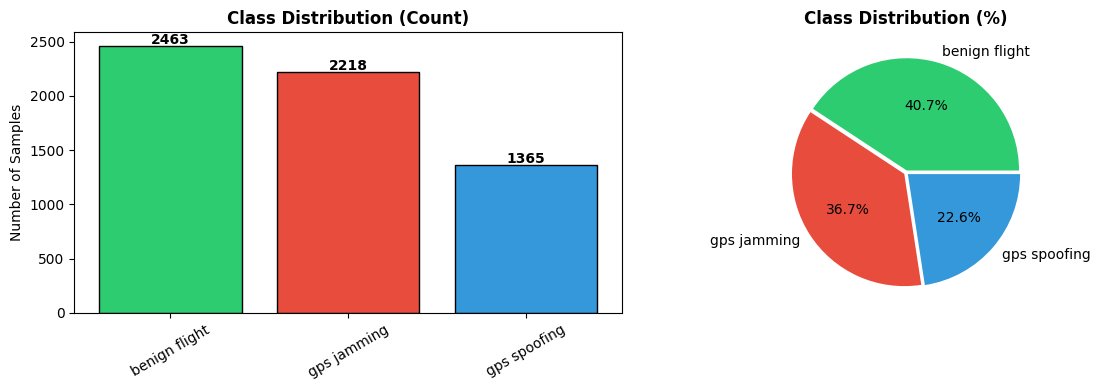

In [13]:
# CLASS DISTRIBUTION VISUALIZATION

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Define colors for each class
colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green, Red, Blue

# Get class distribution
class_distribution = y.value_counts()

# Plot 1: Bar chart showing class counts
bars = axes[0].bar(class_distribution.index, class_distribution.values,
                   color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=30)

# Add count labels on top of bars
for bar, count in zip(bars, class_distribution.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', fontweight='bold')

# Plot 2: Pie chart showing class percentages
axes[1].pie(class_distribution.values, labels=class_distribution.index,
            autopct='%1.1f%%', colors=colors, explode=[0.02]*3)
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

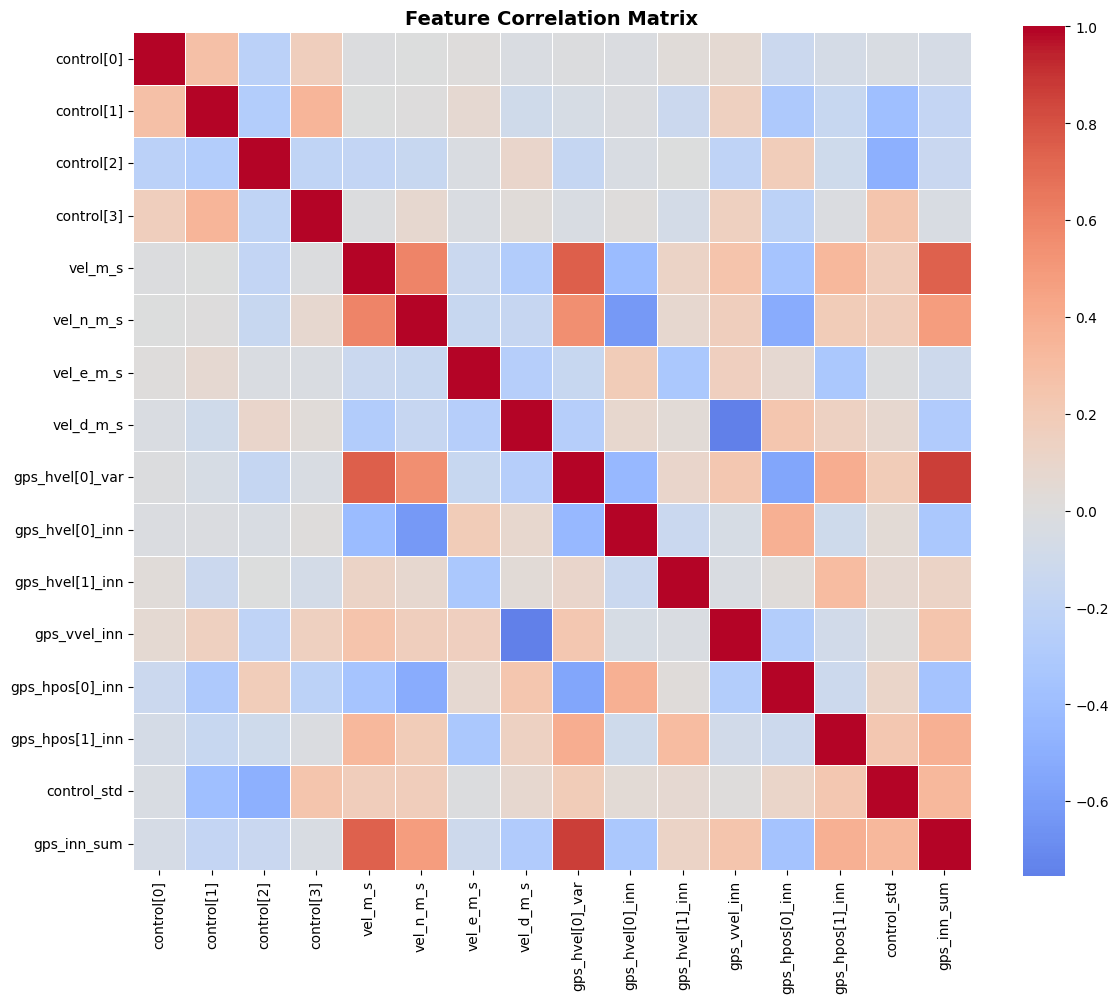

In [14]:
# CORRELATION MATRIX VISUALIZATION

# Create correlation heatmap
plt.figure(figsize=(12, 10))

# Calculate correlation matrix
correlation = X.corr()

# Create heatmap with color-coded correlations
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.5)

plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4. Random Forest Model

Build and train the Random Forest classifier with hyperparameter tuning.

### 4.1 Train-Test Split

In [16]:
# SPLIT DATA INTO TRAINING AND TEST SETS

# Split the data with 80% for training and 20% for testing
# stratify=y_encoded ensures class distribution is preserved in both sets
# random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("TRAIN-TEST SPLIT")
print(f"Training samples: {len(X_train)} (80%)")
print(f"Test samples: {len(X_test)} (20%)")
print(f"Number of features: {X_train.shape[1]}")

TRAIN-TEST SPLIT
Training samples: 4836 (80%)
Test samples: 1210 (20%)
Number of features: 16


## 4.2 Hyperparameter Tuning

In [17]:
# HYPERPARAMETER TUNING USING GRID SEARCH

print("HYPERPARAMETER TUNING")
print("Running GridSearchCV to find optimal parameters...\n")

# Define the parameter grid to search
# These are the hyperparameters we want to optimize
param_grid = {
    'n_estimators': [100, 150],      # Number of trees in the forest
    'max_depth': [8, 10, 12],        # Maximum depth of each tree
    'min_samples_split': [5, 10],    # Minimum samples to split a node
    'min_samples_leaf': [3, 5]       # Minimum samples in a leaf node
}

# Create Stratified K-Fold cross-validator
# This ensures each fold has the same class distribution
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',  # Optimize for weighted F1-score
    n_jobs=-1,              # Use all CPU cores
    verbose=1
)

# Fit the grid search to training data
grid_search.fit(X_train, y_train)

# Display results

print("BEST PARAMETERS FOUND:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING
Running GridSearchCV to find optimal parameters...

Fitting 5 folds for each of 24 candidates, totalling 120 fits
BEST PARAMETERS FOUND:
  max_depth: 12
  min_samples_leaf: 3
  min_samples_split: 5
  n_estimators: 150

Best Cross-Validation Score: 0.8985


## 4.3 Train Final Model

In [18]:
# GET THE BEST MODEL AND MAKE PREDICTION

# Get the best model from grid search
rf_model = grid_search.best_estimator_

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Get prediction probabilities for ROC curve
y_pred_proba = rf_model.predict_proba(X_test)

print("Model training complete")
print(f"\nModel: {rf_model}")

Model training complete

Model: RandomForestClassifier(max_depth=12, min_samples_leaf=3, min_samples_split=5,
                       n_estimators=150, n_jobs=-1, random_state=42)


## 4.4 Cross-Validation Results

In [19]:
# FOLD CROSS-VALIDATION EVALUATION

print("FOLD CROSS-VALIDATION RESULTS")

# Calculate cross-validation scores for different metrics
cv_accuracy = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
cv_precision = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='precision_weighted')
cv_recall = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='recall_weighted')
cv_f1 = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted')

# Display results in a formatted table
print(f"\n{'Metric':<15} {'Mean':>10} {'Std':>10}")
print(f"{'Accuracy':<15} {cv_accuracy.mean():>10.4f} {cv_accuracy.std():>10.4f}")
print(f"{'Precision':<15} {cv_precision.mean():>10.4f} {cv_precision.std():>10.4f}")
print(f"{'Recall':<15} {cv_recall.mean():>10.4f} {cv_recall.std():>10.4f}")
print(f"{'F1-Score':<15} {cv_f1.mean():>10.4f} {cv_f1.std():>10.4f}")

FOLD CROSS-VALIDATION RESULTS

Metric                Mean        Std
Accuracy            0.8983     0.0098
Precision           0.8983     0.0098
Recall              0.8983     0.0098
F1-Score            0.8981     0.0097


## 4.5 Feature Importance Analysis

In [20]:
# FEATURE IMPORTANCE ANALYSIS

# Create DataFrame with feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top features
print("FEATURE IMPORTANCE")

for rank, (_, row) in enumerate(feature_importance.iterrows(), 1):
    # Create visual bar using characters
    bar = '█' * int(row['Importance'] * 40)
    print(f"{rank:2d}. {row['Feature']:<25} {row['Importance']:.4f} {bar}")

FEATURE IMPORTANCE
 1. control[3]                0.3128 ████████████
 2. gps_hvel[0]_var           0.1082 ████
 3. gps_vvel_inn              0.0961 ███
 4. control_std               0.0738 ██
 5. gps_hpos[0]_inn           0.0622 ██
 6. control[2]                0.0599 ██
 7. vel_d_m_s                 0.0508 ██
 8. gps_hpos[1]_inn           0.0459 █
 9. gps_inn_sum               0.0402 █
10. vel_n_m_s                 0.0367 █
11. vel_m_s                   0.0337 █
12. vel_e_m_s                 0.0243 
13. gps_hvel[1]_inn           0.0155 
14. gps_hvel[0]_inn           0.0149 
15. control[1]                0.0127 
16. control[0]                0.0123 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

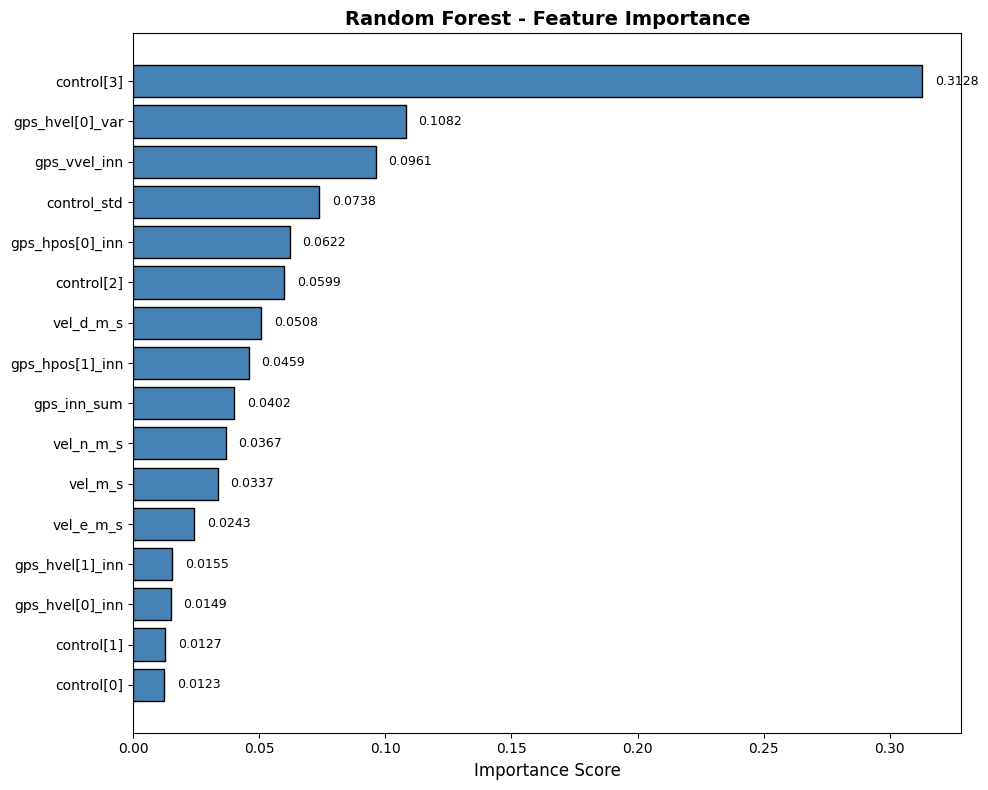

In [31]:
# FEATURE IMPORTANCE VISUALIZATION

# Create horizontal bar chart
plt.figure(figsize=(10, 8))

# Plot bars
bars = plt.barh(range(len(feature_importance)),
                feature_importance['Importance'],
                color='steelblue', edgecolor='black')

# Set y-axis labels
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])

# Labels and title
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')

# Invert y-axis so most important is at top
plt.gca().invert_yaxis()

# Add value labels
for bar, value in zip(bars, feature_importance['Importance']):
    plt.text(value + 0.005, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.pdf', format='pdf', dpi=150, bbox_inches='tight')
try:
    files.download('feature_importance.pdf')
except:
    pass
plt.show()


## 4.6 Confusion Matrix

In [26]:
from google.colab import files

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 800x600 with 0 Axes>

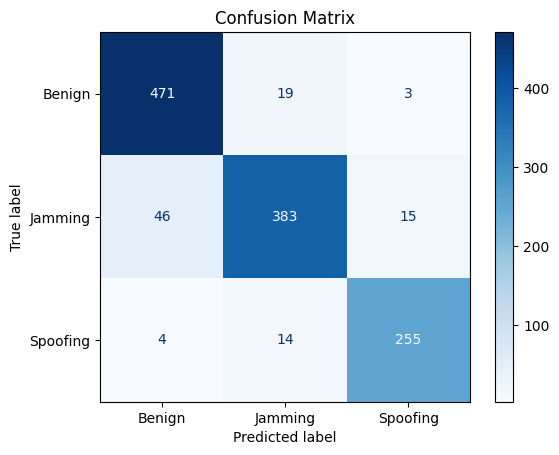

In [27]:
# CONFUSION MATRIX VISUALIZATION

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Jamming', 'Spoofing'])
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')

try:
    files.download('confusion_matrix.pdf')
except:
    pass

plt.show()

In [28]:
# Plot 2: Confusion matrix with percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 12})
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_title('Confusion Matrix (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

## 4.7 ROC Curve

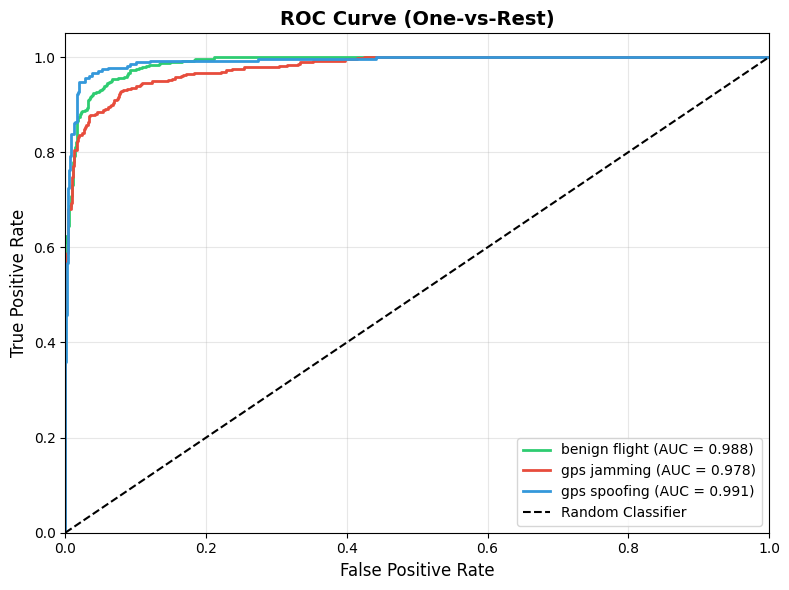

In [29]:
# ROC CURVE VISUALIZATION (ONE-VS-REST)

# Binarize the test labels for multi-class ROC
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Create ROC curve plot
plt.figure(figsize=(8, 6))

# Plot ROC curve for each class
for i, (color, class_name) in enumerate(zip(colors, classes)):
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot the curve
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')

# Set axis limits and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Overall Metrics

Comprehensive evaluation of model performance.

In [30]:
# DETAILED CLASSIFICATION REPORT

print("CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, y_pred, target_names=classes, digits=4))

CLASSIFICATION REPORT
               precision    recall  f1-score   support

benign flight     0.9040    0.9554    0.9290       493
  gps jamming     0.9207    0.8626    0.8907       444
 gps spoofing     0.9341    0.9341    0.9341       273

     accuracy                         0.9165      1210
    macro avg     0.9196    0.9174    0.9179      1210
 weighted avg     0.9169    0.9165    0.9161      1210

